In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. Загружаем стандартизированный датасет из 1-й лабы
df = pd.read_csv('dataset_standardized.csv')

# 2. Оставляем непрерывные аудио-признаки
# Выкидываем текст, популярность и все One-Hot колонки (жанры, тональность, explicit), зачем нам открывать америку
cols_to_keep =[
    'duration_ms', 'tempo', 'loudness', 'danceability', 'energy', 
    'speechiness', 'acousticness', 'instrumentalness', 'liveness', 
    'valence', 'time_signature'
]
X_full = df[cols_to_keep]

# 3. делаем сэмплик
# Берем 3000 случайных треков
np.random.seed(42)
sample_indices = np.random.choice(X_full.shape[0], size=3000, replace=False)

# Наш финальный набор данных для всей 4-й лабы
X = X_full.iloc[sample_indices].reset_index(drop=True)

print("Данные для 4-й лабы готовы!")
print(f"Размер выборки: {X.shape} (3000 треков, {X.shape[1]} чистых аудио-признаков)")

Данные для 4-й лабы готовы!
Размер выборки: (3000, 11) (3000 треков, 11 чистых аудио-признаков)


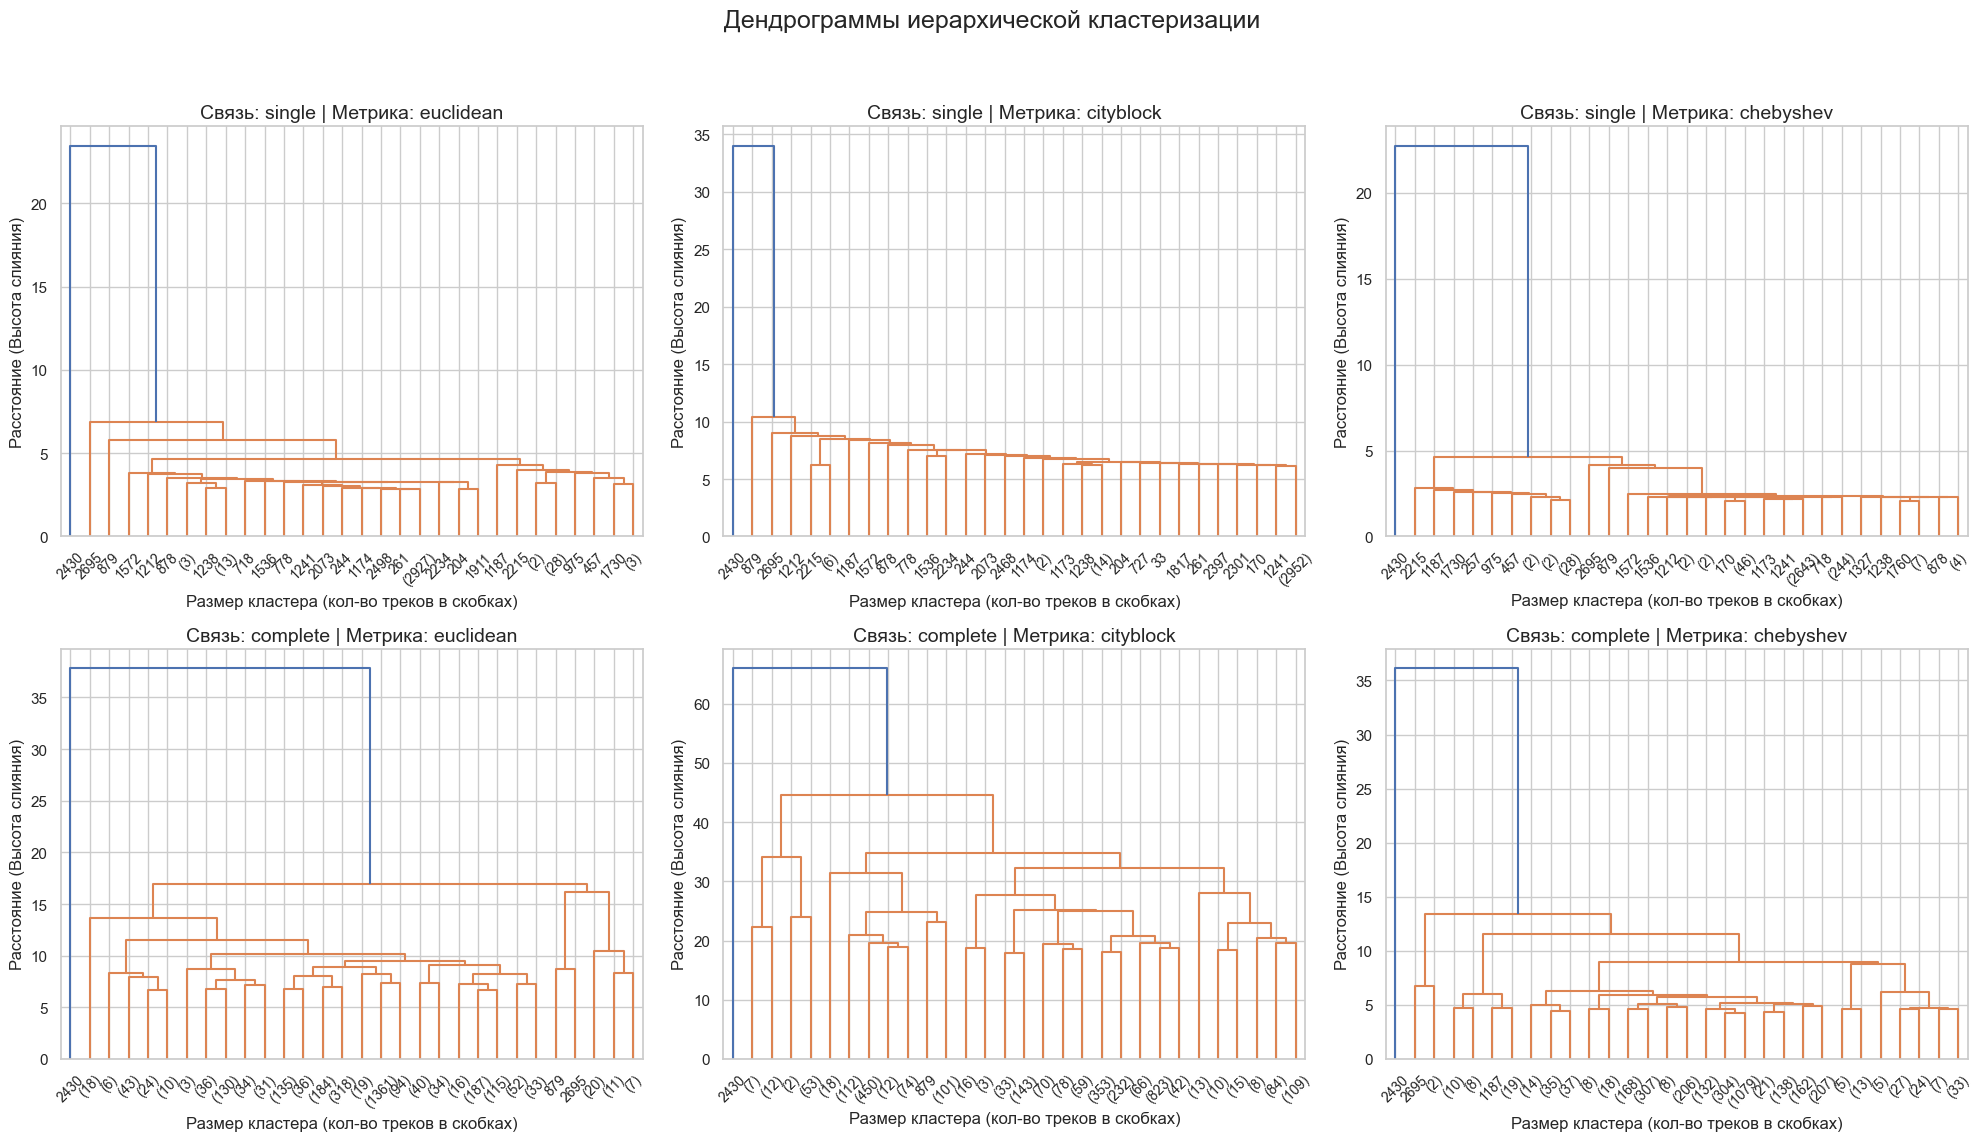

In [2]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Этап 1: Иерархическая кластеризация (Дендрограммы)

# Задаем списки методов и метрик по заданию
methods =['single', 'complete']
metrics = ['euclidean', 'cityblock', 'chebyshev']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Дендрограммы иерархической кластеризации', fontsize=18)

# Словарь для сохранения матриц связей (пригодятся для разбиения на кластеры)
linkage_matrices = {}

for i, method in enumerate(methods):
    for j, metric in enumerate(metrics):
        # Вычисляем матрицу связей (Z)
        # Алгоритм строит дерево, попарно соединяя все 3000 точек
        Z = linkage(X, method=method, metric=metric)
        
        # Сохраняем в словарь 
        dict_key = f"{method}_{metric}"
        linkage_matrices[dict_key] = Z
        
        # 2. Строим дендрограмму
        ax = axes[i, j]
        # truncate_mode='lastp', p=30 чтобы рисовал не все 3000 веток,
        # а только 30 самых верхних больших слияний.
        dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, show_leaf_counts=True)
        
        ax.set_title(f'Связь: {method} | Метрика: {metric}', fontsize=14)
        ax.set_xlabel('Размер кластера (кол-во треков в скобках)')
        ax.set_ylabel('Расстояние (Высота слияния)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

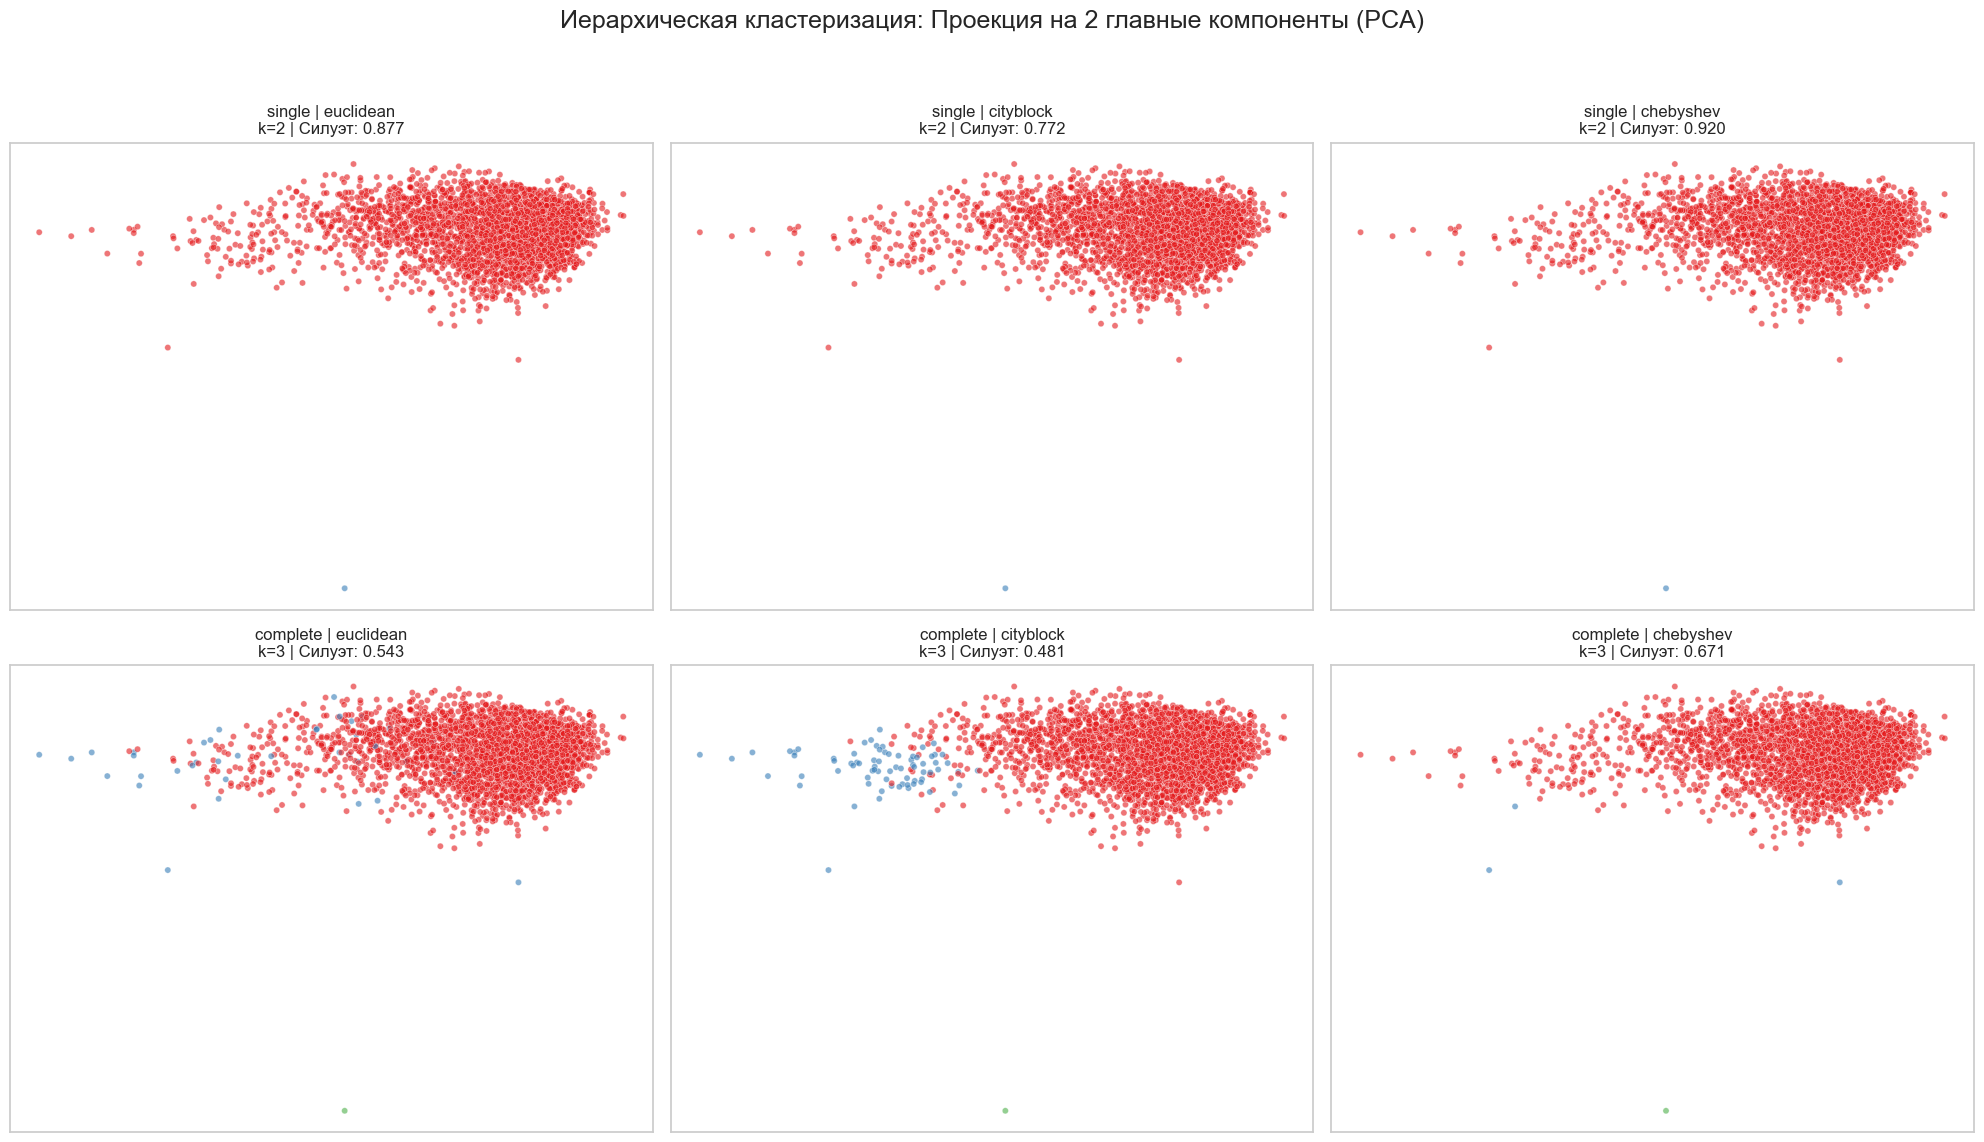

Результаты Иерархической кластеризации:


,Алгоритм,Метод связи,Метрика,Кол-во кластеров (k),Силуэт
0,Agglomerative (Иерархическая),single,euclidean,2,0.876638
1,Agglomerative (Иерархическая),single,cityblock,2,0.771917
2,Agglomerative (Иерархическая),single,chebyshev,2,0.920061
3,Agglomerative (Иерархическая),complete,euclidean,3,0.543158
4,Agglomerative (Иерархическая),complete,cityblock,3,0.480579
5,Agglomerative (Иерархическая),complete,chebyshev,3,0.670693


In [13]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Этап 1, часть 2: Разбиение, PCA визуализация и расчет Силуэта

# определили оптимальные k 
# Для single  2 
# Для complete берем 3 
# Для товарища чебышева 4 отлично смотрится
optimal_k = {
    'single_euclidean': 2,
    'single_cityblock': 2,
    'single_chebyshev': 2,
    'complete_euclidean': 3,
    'complete_cityblock': 3,
    'complete_chebyshev': 3
}

# Подготовим PCA, чтобы сжать 11 колонок в 2 координаты для рисования картинок
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Иерархическая кластеризация: Проекция на 2 главные компоненты (PCA)', fontsize=18)

# Сюда будем сохранять результаты Силуэты
results_hierarchical =[]

for i, method in enumerate(methods):
    for j, metric in enumerate(metrics):
        dict_key = f"{method}_{metric}"
        k = optimal_k[dict_key]
        
        # Запускаем кластеризацию
        cluster_model = AgglomerativeClustering(n_clusters=k, linkage=method, metric=metric)
        # Получаем метки для каждого трека
        cluster_labels = cluster_model.fit_predict(X)
        
        # Считаем коэффициент Силуэта
        silhouette = silhouette_score(X, cluster_labels, metric=metric)
        results_hierarchical.append({
            'Алгоритм': 'Agglomerative (Иерархическая)',
            'Метод связи': method,
            'Метрика': metric,
            'Кол-во кластеров (k)': k,
            'Силуэт': silhouette
        })
        
        ax = axes[i, j]
        sns.scatterplot(
            x=X_pca_2d[:, 0], 
            y=X_pca_2d[:, 1], 
            hue=cluster_labels.astype(str),
            palette='Set1',                
            alpha=0.6, 
            s=20, 
            legend=False,                  
            ax=ax                        
        )
        ax.set_title(f'{method} | {metric}\nk={k} | Силуэт: {silhouette:.3f}')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

results_df = pd.DataFrame(results_hierarchical)
print("Результаты Иерархической кластеризации:")
display(results_df)

### Выводы по Этапу 1 Иерархическая кластеризация

1. Оценка метода одиночной связи: Метод показал ярко выраженный эффект цепочки. Алгоритм обособляет единичные выбросы, оставляя большинство данных в одном огромном кластере. Практическая ценность такого разбиения нулевая, хотя значение силуэта вполне себе.
2. Вывод по Евклидовой complete и Чебышева complete: график показал что при k=3 эти метрики ведут себя схожим с single образом, они отделяют небольшие группы группы по паре точек оставляя основную массу данных в одном огромном кластере.
3. Манхэттенская метрика complete  cityblock дала осмысленное разделение, несмотря на низкое значение силуэта.

Считаем 'Метод локтя' для Евклидовой K-Means и Манхэттенской K-Medoids метрик...


C:\Users\Danya\Desktop\MAD\UNI_MAD\venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\Danya\Desktop\MAD\UNI_MAD\venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\Danya\Desktop\MAD\UNI_MAD\venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly inst

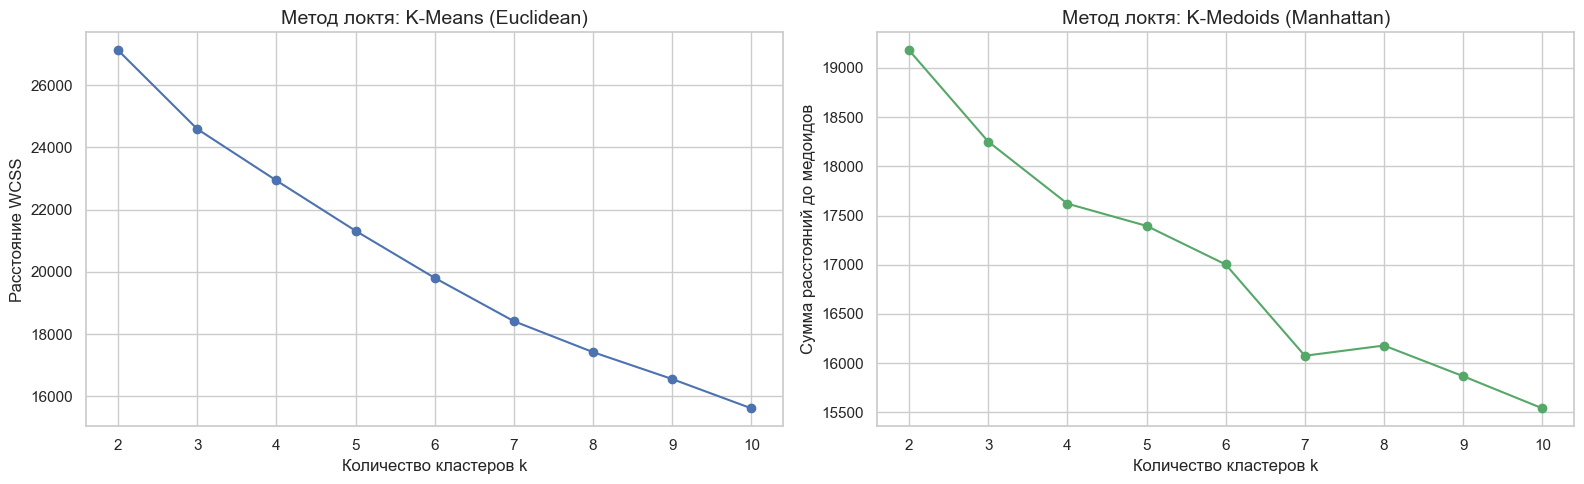


Обучаем K-Means (Euclidean) для k=2...
Силуэт (euclidean): 0.249

Обучаем K-Medoids (Manhattan) для k=2...


C:\Users\Danya\Desktop\MAD\UNI_MAD\venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Силуэт (manhattan): 0.274

Обучаем K-Means (Euclidean) для k=3...
Силуэт (euclidean): 0.143

Обучаем K-Medoids (Manhattan) для k=3...


C:\Users\Danya\Desktop\MAD\UNI_MAD\venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Силуэт (manhattan): 0.136


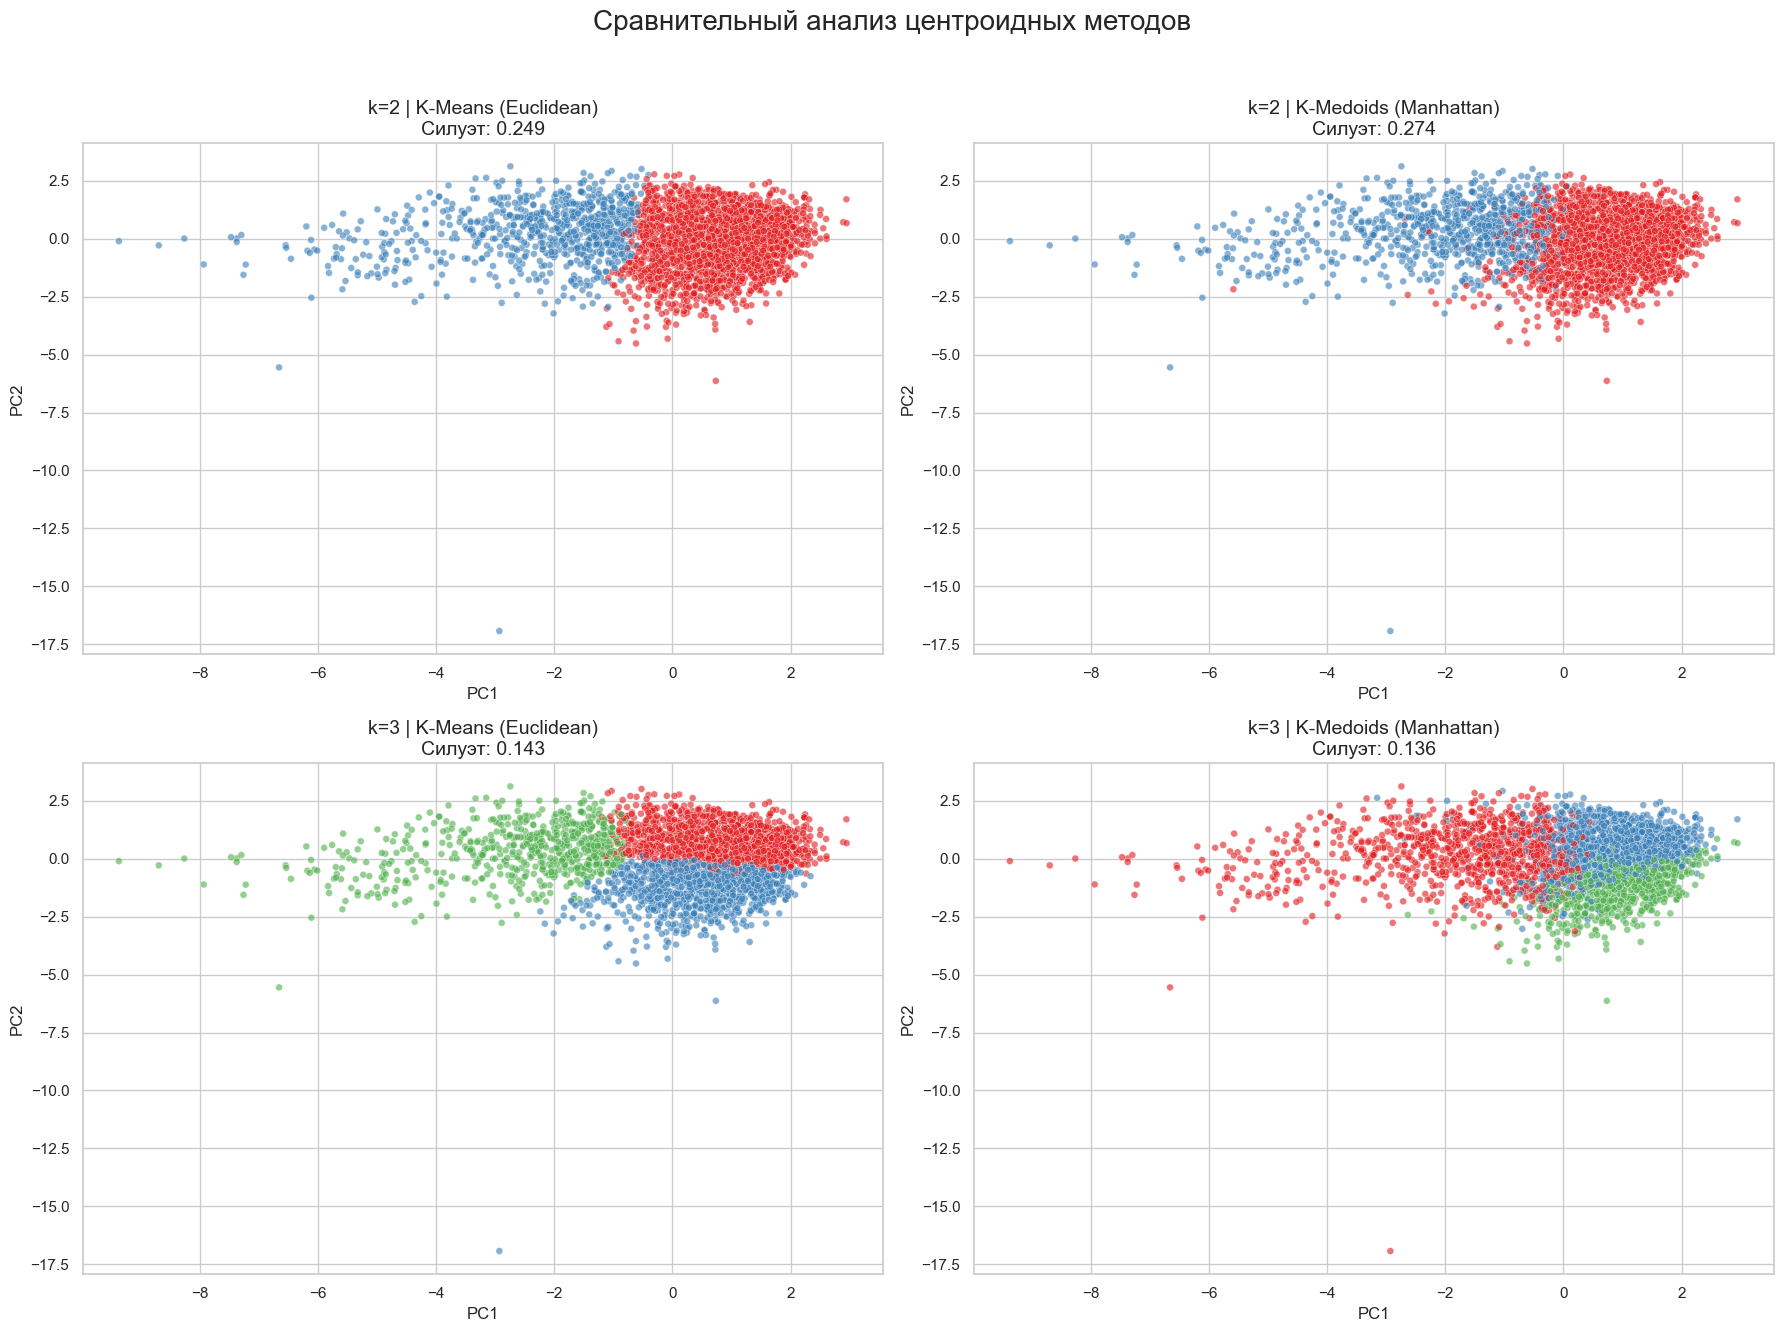

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

# Этап 2, часть 1: Метод локтя для двух метрик
print("Считаем 'Метод локтя' для Евклидовой K-Means и Манхэттенской K-Medoids метрик...")

wcss_euclidean = []
wcss_manhattan =[]
K_range = range(2, 11)

for k in K_range:
    # K-Means Евклидова
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss_euclidean.append(kmeans.inertia_) 
    
    # K-Medoids Манхэттенская
    kmedoids = KMedoids(n_clusters=k, metric='manhattan', init='k-medoids++', random_state=42)
    kmedoids.fit(X)
    wcss_manhattan.append(kmedoids.inertia_)

# Строим графики локтя рядом
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, wcss_euclidean, marker='o', linestyle='-', color='b')
axes[0].set_title('Метод локтя: K-Means (Euclidean)', fontsize=14)
axes[0].set_xlabel('Количество кластеров k')
axes[0].set_ylabel('Расстояние WCSS')
axes[0].set_xticks(K_range)
axes[0].grid(True)

axes[1].plot(K_range, wcss_manhattan, marker='o', linestyle='-', color='g')
axes[1].set_title('Метод локтя: K-Medoids (Manhattan)', fontsize=14)
axes[1].set_xlabel('Количество кластеров k')
axes[1].set_ylabel('Сумма расстояний до медоидов')
axes[1].set_xticks(K_range)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# --- Этап 2, часть 2: Финальная кластеризация 2х2 (k vs Метрики) ---

# Список k, которые мы сравниваем
k_values_to_compare =[2, 3]
# Список метрик
metrics_to_compare =['euclidean', 'manhattan']

fig, axes = plt.subplots(len(k_values_to_compare), len(metrics_to_compare), figsize=(18, 14))
fig.suptitle('Сравнительный анализ центроидных методов', fontsize=20)

results_kmeans =[]

for i, k in enumerate(k_values_to_compare):
    for j, metric in enumerate(metrics_to_compare):
        
        # Выбираем правильную модель
        if metric == 'euclidean':
            model_name = 'K-Means (Euclidean)'
            model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        else: # metric == 'manhattan'
            model_name = 'K-Medoids (Manhattan)'
            model = KMedoids(n_clusters=k, metric=metric, init='k-medoids++', random_state=42)
            
        print(f"\nОбучаем {model_name} для k={k}...")
        
        # 1. Обучение
        labels = model.fit_predict(X)
        
        # 2. Силуэт с СООТВЕТСТВУЮЩЕЙ метрикой
        silhouette = silhouette_score(X, labels, metric=metric if metric != 'manhattan' else 'cityblock')
        print(f"Силуэт ({metric}): {silhouette:.3f}")
        
        results_kmeans.append({
            'Алгоритм': model_name,
            'Метрика': metric,
            'Кол-во кластеров (k)': k,
            'Силуэт': silhouette
        })
        
        # 3. Визуализация
        ax = axes[i, j]
        sns.scatterplot(
            x=X_pca_2d[:, 0], 
            y=X_pca_2d[:, 1], 
            hue=labels.astype(str), 
            palette='Set1', 
            alpha=0.6, s=25, legend=False, ax=ax
        )
        ax.set_title(f"k={k} | {model_name}\nСилуэт: {silhouette:.3f}", fontsize=14)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Выводы по Этапу 2 Алгоритм K-Means

График метода локтя не показал явного сгиба, что говорит об отсутствии в данных четких сферических кластеров.
Для выполнения требований задания был проведен сравнительный анализ двух метрик при k=2 и k=3.
При k=2 оба алгоритма разделили данные на два осмысленных сегмента. Манхэттенская метрика показала лучший результат по силуэту.
При k=3 оба алгоритма начали искусственно дробить облако на доли что привело к падению коэффициента силуэта.
Вывод: для данных такого типа центроидные методы подходят слабо. Наиболее устойчивый результат показал Manhattan при k=2.

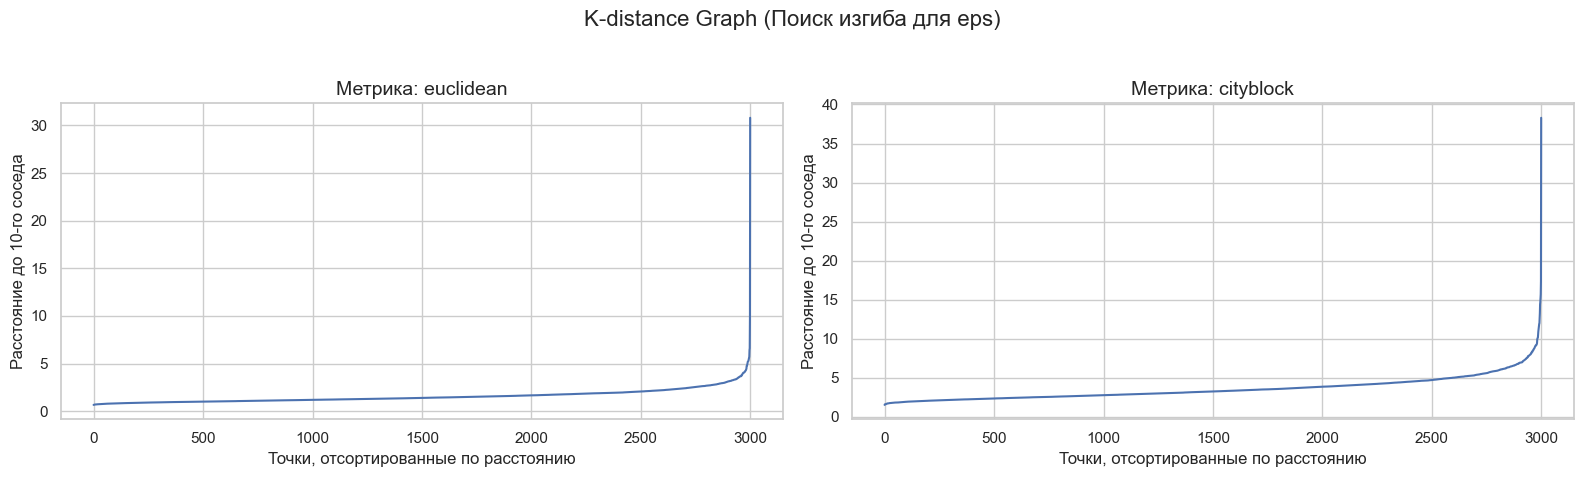


Запускаем DBSCAN с перебором eps для каждой метрики...


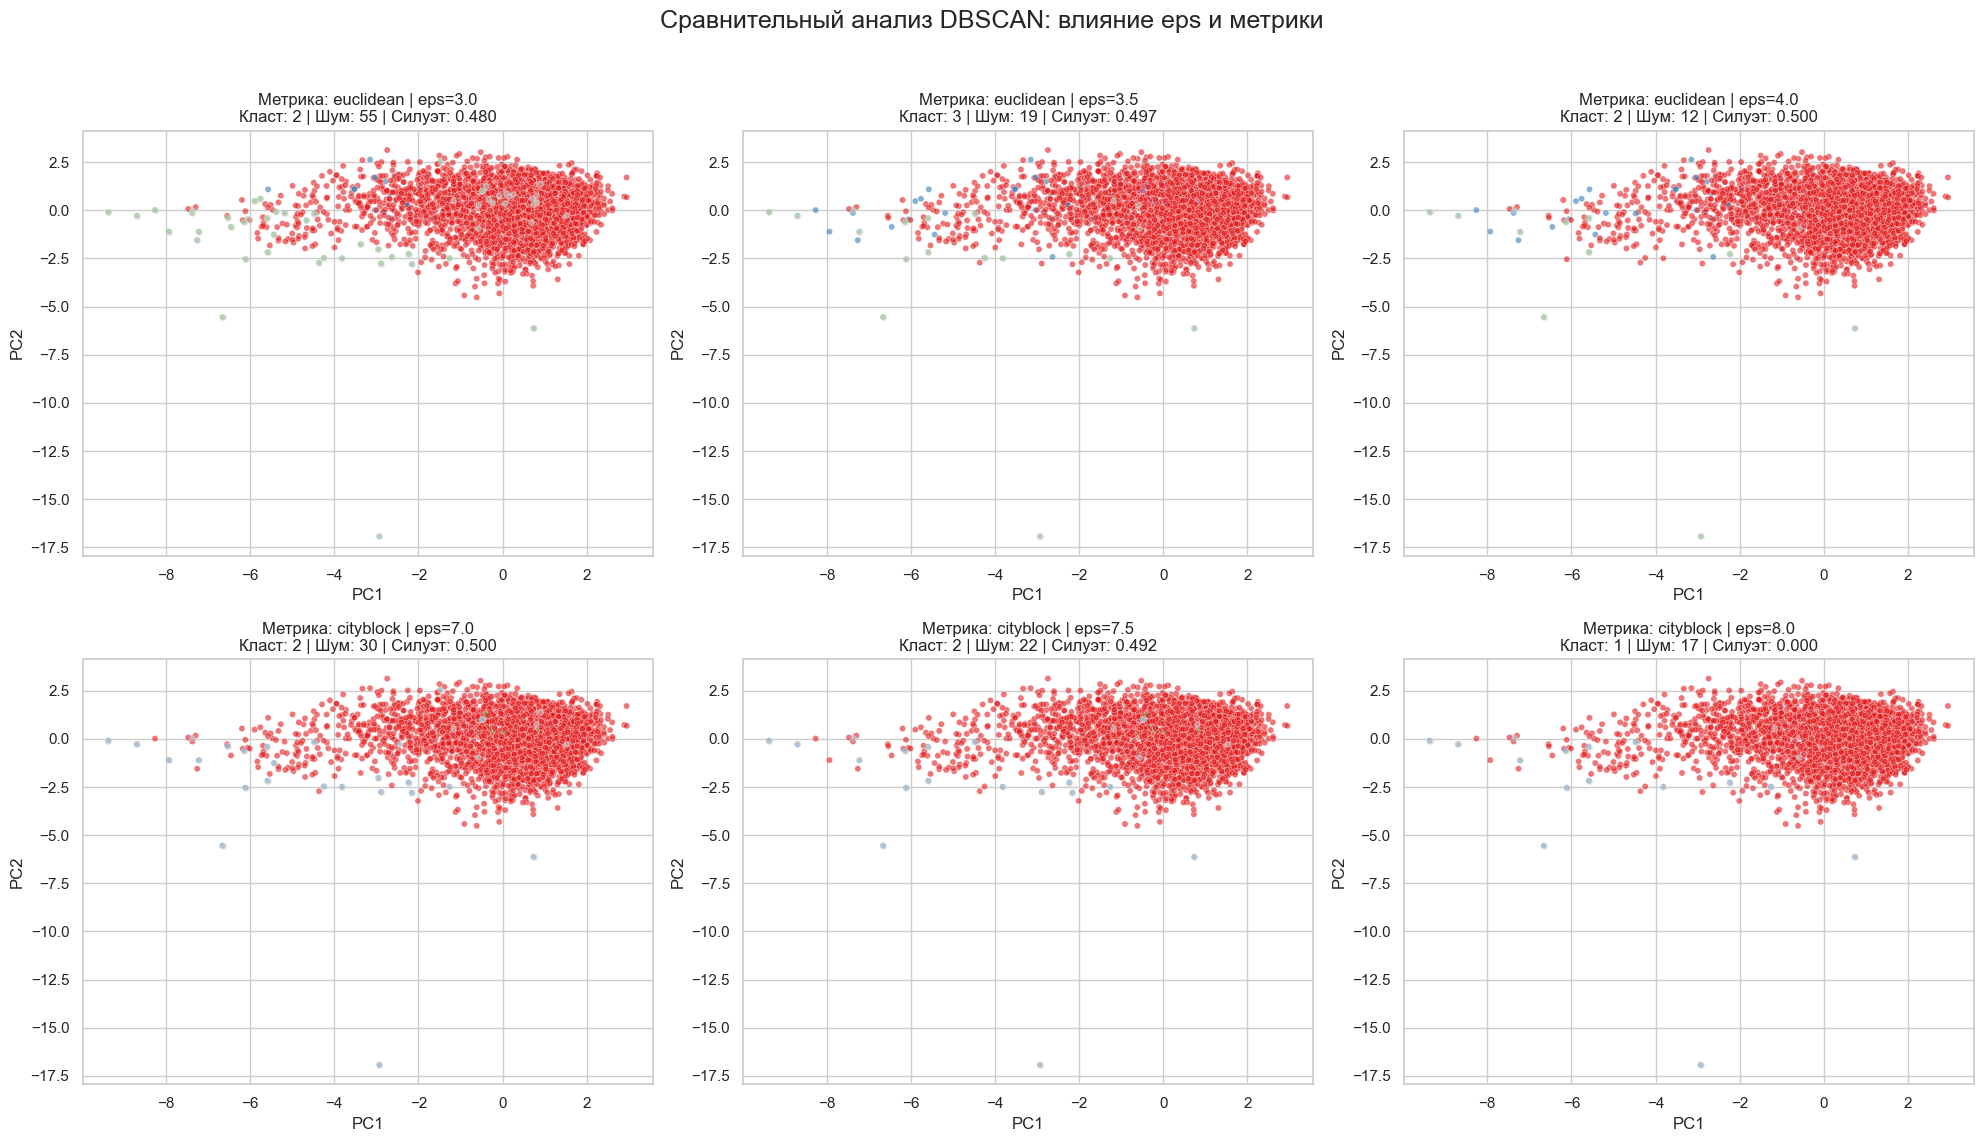

In [17]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# --- Этап 3, Часть 1: Поиск радиуса eps для КАЖДОЙ метрики (K-distance Graph) ---

min_pts = 10
metrics_dbscan = ['euclidean', 'cityblock']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('K-distance Graph (Поиск изгиба для eps)', fontsize=16)

for i, metric in enumerate(metrics_dbscan):
    # Ищем 10-го соседа с нужной метрикой
    neighbors = NearestNeighbors(n_neighbors=min_pts, metric=metric)
    neighbors_fit = neighbors.fit(X)
    distances, indices = neighbors_fit.kneighbors(X)

    # Сортируем расстояния
    distances = np.sort(distances[:, min_pts-1], axis=0)

    axes[i].plot(distances)
    axes[i].set_title(f'Метрика: {metric}', fontsize=14)
    axes[i].set_xlabel('Точки, отсортированные по расстоянию')
    axes[i].set_ylabel(f'Расстояние до {min_pts}-го соседа')
    axes[i].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- Этап 3, Часть 2: Сравнительный анализ DBSCAN с перебором eps ---
print("\nЗапускаем DBSCAN с перебором eps для каждой метрики...")

# Базовые значения eps, найденные по графикам K-distance
base_eps_euclidean = 3.5
base_eps_manhattan = 7.5
min_pts = 10

# Списки метрик и eps для перебора
params_to_test =[
    {'metric': 'euclidean', 'eps_list': [base_eps_euclidean - 0.5, base_eps_euclidean, base_eps_euclidean + 0.5]},
    {'metric': 'cityblock', 'eps_list': [base_eps_manhattan - 0.5, base_eps_manhattan, base_eps_manhattan + 0.5]}
]

# Создаем большой холст 2x3
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Сравнительный анализ DBSCAN: влияние eps и метрики', fontsize=18)

results_dbscan =[]

for i, params in enumerate(params_to_test):
    metric = params['metric']
    for j, current_eps in enumerate(params['eps_list']):
        
        # Обучаем DBSCAN
        dbscan = DBSCAN(eps=current_eps, min_samples=min_pts, metric=metric)
        labels_db = dbscan.fit_predict(X)
        
        # Считаем статистику
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = list(labels_db).count(-1)
        
        mask = labels_db != -1
        if len(set(labels_db[mask])) > 1:
            silhouette = silhouette_score(X[mask], labels_db[mask], metric=metric)
        else:
            silhouette = 0.0
            
        results_dbscan.append({
            'Алгоритм': 'DBSCAN',
            'Метрика': metric,
            'eps': current_eps,
            'Кластеров': n_clusters,
            'Шум (точек)': n_noise,
            'Силуэт': silhouette
        })
        
        # Визуализация
        ax = axes[i, j]
        sns.scatterplot(
            x=X_pca_2d[:, 0], 
            y=X_pca_2d[:, 1], 
            hue=labels_db.astype(str), 
            palette='Set1', alpha=0.6, s=20, legend=False, ax=ax
        )
        # Шум красим серым поверх
        noise_mask = labels_db == -1
        ax.scatter(X_pca_2d[noise_mask, 0], X_pca_2d[noise_mask, 1], c='lightgrey', alpha=0.5, s=15)
        
        ax.set_title(f"Метрика: {metric} | eps={current_eps}\nКласт: {n_clusters} | Шум: {n_noise} | Силуэт: {silhouette:.3f}", fontsize=12)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

#### Выводы по Этапу 3 Алгоритм DBSCAN
Поиск оптимальных eps проводился для метрик euclidean и cityblock с помощью K-distance графиков. Оптимальные значения eps находятся в районе 3.5 для Евклидовой и 7.5 для Манхэттенской метрики.
Проведенный перебор eps для обеих метрик показал, что DBSCAN не подходит для кластеризации данного набора аудио-признаков. Алгоритм либо сливает 95-99% всех точек в один гигантский кластер, либо при малых eps не находит связей вовсе, объявляя почти все точки шумом.
Максимальный Силуэт 0.500 достигается при eps=4.0 и eps=7.0, однако визуально это разбиение не несет практического смысла: от основного массива отделяется лишь небольшой кластер из 20-30 точек.
Вывод: DBSCAN неэффективен на данных с непрерывной, плавно меняющейся плотностью, так как в них отсутствуют четкие пустые границы между кластерами, необходимые для работы алгоритма.

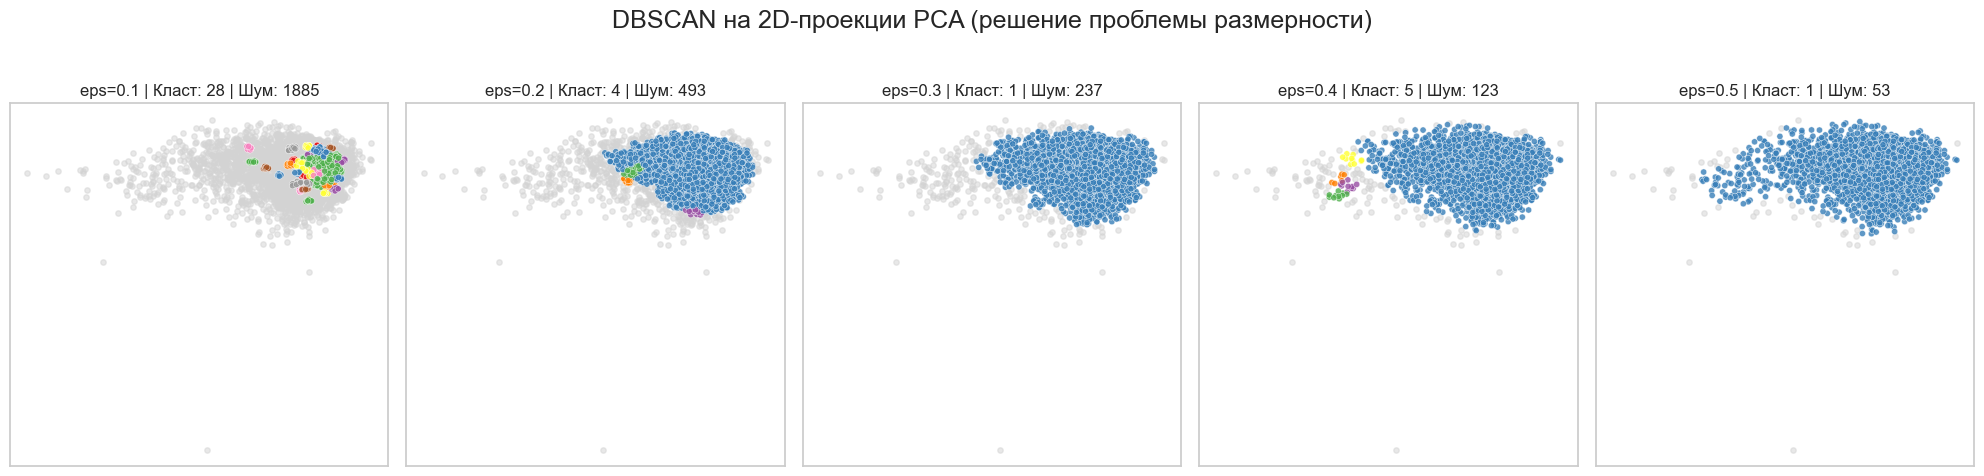

In [6]:
# Бонус-этап где мы пытаемся заставить работать дбскан в 2д

# Зададим новые, маленькие радиусы, так как в 2д расстояния меньше
eps_values =[0.1, 0.2, 0.3, 0.4, 0.5]
min_pts = 10

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('DBSCAN на 2D-проекции PCA (решение проблемы размерности)', fontsize=18)

results_dbscan =[]

for i, current_eps in enumerate(eps_values):
    # Обучаем DBSCAN на X_pca_2d
    dbscan = DBSCAN(eps=current_eps, min_samples=min_pts, metric='euclidean')
    labels_db = dbscan.fit_predict(X_pca_2d)
    
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = list(labels_db).count(-1)
    
    mask = labels_db != -1
    if len(set(labels_db[mask])) > 1:
        silhouette = silhouette_score(X_pca_2d[mask], labels_db[mask], metric='euclidean')
    else:
        silhouette = 0.0
        
    # Визуализация 
    ax = axes[i]
    unique_labels = [str(l) for l in np.unique(labels_db)]
    custom_palette = sns.color_palette("Set1", len(unique_labels))
    color_dict = dict(zip(unique_labels, custom_palette))
    if '-1' in color_dict: color_dict['-1'] = 'lightgrey'
        
    noise_mask = labels_db == -1
    ax.scatter(X_pca_2d[noise_mask, 0], X_pca_2d[noise_mask, 1], c='lightgrey', alpha=0.5, s=15)
    
    cluster_mask = labels_db != -1
    if np.any(cluster_mask):
        sns.scatterplot(
            x=X_pca_2d[cluster_mask, 0], 
            y=X_pca_2d[cluster_mask, 1], 
            hue=labels_db[cluster_mask].astype(str), 
            palette=color_dict, 
            alpha=0.8, s=20, ax=ax, legend=False
        )
        
    ax.set_title(f'eps={current_eps} | Класт: {n_clusters} | Шум: {n_noise}', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4. Сравнение результатов

| Алгоритм | Метрика | k | Силуэт | Визуальная оценка |
|---|---|---|---|---|
| Иерархическая (single) | euclidean | 2 | 0.877 | Один массив + единичные выбросы |
| Иерархическая (single) | cityblock | 2 | 0.772 | Один массив + единичные выбросы |
| Иерархическая (single) | chebyshev | 2 | 0.920 | Один массив + единичные выбросы |
| Иерархическая (complete) | euclidean | 3 | 0.543 | Один массив + малая группа |
| Иерархическая (complete) | cityblock | 3 | 0.481 | Наиболее осмысленное разделение |
| Иерархическая (complete) | chebyshev | 3 | 0.671 | Один массив + малая группа |
| K-Means | euclidean | 2 | 0.249 | Два перекрывающихся сегмента |
| K-Medoids | manhattan | 2 | 0.274 | Два перекрывающихся сегмента |
| K-Means | euclidean | 3 | 0.143 | Искусственное дробление облака |
| K-Medoids | manhattan | 3 | 0.136 | Искусственное дробление облака |
| DBSCAN | euclidean, eps=4.0 | 2 | 0.500 | Массив + 12 выбросов |
| DBSCAN | cityblock, eps=7.0 | 2 | 0.500 | Массив + 30 выбросов |

Лучшую метрику по силуэту в иерархической кластеризации показала Чебышева при методе single, однако это результат статистически бессмысленный — алгоритм просто отщепил несколько выбросов. При complete linkage наиболее осмысленное разбиение дала Манхэттенская метрика. Для K-Means и K-Medoids Manhattan незначительно, но стабильно превосходит Евклидову. В DBSCAN обе метрики показали одинаковый максимальный силуэт 0.500.

Главный вывод раздела: ни один из методов не создал содержательной кластерной структуры. Данные представляют собой непрерывное облако без чётких границ, что подтверждается отсутствием сгиба на методе локтя, поведением DBSCAN и визуальным анализом PCA-проекций. Высокие значения силуэта у single linkage объясняются не качеством кластеризации, а математическим артефактом — отделением единичных выбросов от основной массы.

Какая метрика расстояния дала наилучший результат для каждого алгоритма?
Для иерархической кластеризации формально лучший силуэт показала метрика Чебышева при методе single (0.920), однако это результат-артефакт: алгоритм отщепил единичные выбросы, оставив всё остальное в одном кластере. Если оценивать осмысленность разбиения, то при complete linkage лучшей оказалась Манхэттенская метрика — она единственная дала хоть какое-то реальное разделение облака на части.
Для K-Means и K-Medoids Манхэттенская метрика стабильно превзошла Евклидову при обоих значениях k, хотя разница невелика: 0.274 против 0.249 при k=2.
Для DBSCAN обе метрики показали одинаковый максимальный силуэт 0.500, поэтому выделить победителя невозможно.

Для какого типа данных каждый метод подходит лучше всего?
Иерархическая кластеризация с complete linkage хорошо работает на компактных, примерно сферических кластерах примерно одинакового размера. На нашем наборе этот метод справился хуже всего именно потому, что данные — одно сплошное облако без чётких границ, что видно на всех PCA-проекциях. Single linkage теоретически хорош для вытянутых, цепочечных структур, но на практике страдает от эффекта цепочки и легко ломается выбросами, что и продемонстрировали наши дендрограммы.
K-Means лучше всего подходит для данных с выраженными сферическими кластерами примерно одинаковой плотности и размера. График метода локтя наглядно показал, что таких структур в данных нет — сгиба не возникло, а силуэт при k=3 упал до 0.143, что говорит об искусственном дроблении одного облака.
DBSCAN лучше всего подходит для данных с кластерами произвольной формы и явным шумом, при условии что между кластерами есть пустые зоны с низкой плотностью. На нашем наборе алгоритм полностью провалился именно из-за отсутствия таких зон — K-distance графики показали плавный, без изгиба рост расстояний, а при любом eps алгоритм либо сливал всё в один кластер, либо объявлял большинство точек шумом.